# WRF U-Net Downscaling: Training, Testing, and Inference

This notebook trains a small U-Net to improve coarse WRF output into a fine 48 x 48 grid, tests it on a held-out year, and then runs inference to save predicted fine-grid NPZ files.

The data preprocessing details are taught in a separate notebook:

`WRF_Data_Preprocessing_Colab.ipynb`

Here we use the ready-made `WRFNPZDataset` so the main notebook can focus on model training, testing, checkpoint saving, inference, and diagnostic plots.

## 1. Learning Goals

By the end of this notebook, students should be able to:

1. Load the prepared WRF dataset with PyTorch.
2. Build a small U-Net for residual downscaling.
3. Train with mini-batches.
4. Test on a held-out year.
5. Save and reload a checkpoint.
6. Run inference year by year and save predicted NPZ files.
7. Plot coarse, predicted, and fine examples.

## 2. Set Up Paths

This cell finds the teaching folder, data folder, stats files, and output folder.

Run this notebook from inside the `dl_downscaling_teaching` directory so the local imports resolve correctly.


In [11]:
import os

import config as cfg

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print("Teaching directory:", cfg.PROJECT_DIR)
print("Data directory:    ", cfg.DATA_DIR)
print("Stats directory:   ", cfg.STATS_DIR)
print("Output directory:  ", cfg.OUTPUT_DIR)


Teaching directory: /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching
Data directory:     /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching/data
Stats directory:    /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching
Output directory:   /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching/outputs


## 3. Import Libraries

PyTorch handles tensors, the model, and training. The helper files in this folder keep the notebook code shorter.


In [12]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

from Network import UNet
from dataset import WRFNPZDataset
from utils import *

# Use the GPU when Colab gives us one. Otherwise use the CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)


Using device: cpu


## 4. Choose A Small Training Run

These defaults are intentionally small for teaching. More epochs usually improve the loss curve, but also take longer.


In [13]:
print("Train years:       ", cfg.TRAIN_YEARS)
print("Test years:        ", cfg.TEST_YEARS)
print("Inference years:   ", cfg.INFERENCE_YEARS)
print("Epochs:            ", cfg.NUM_EPOCHS)
print("Batch size:        ", cfg.BATCH_SIZE)
print("Learning rate:     ", cfg.LEARNING_RATE)

Train years:        [2019]
Test years:         [2018]
Inference years:    [2018]
Epochs:             20
Batch size:         8
Learning rate:      3e-05


## 5. Load Normalization Statistics

The model learns better when every channel is on a similar scale. We use raw-weather statistics for inputs and residual statistics for targets.


In [14]:
raw_mean, raw_std = load_channel_stats(cfg.RAW_STATS, cfg.DL_OUT_SINGLE_LAYER_PARAMS)
residual_mean, residual_std = load_channel_stats(
    cfg.RESIDUAL_STATS,
    cfg.DL_OUT_SINGLE_LAYER_PARAMS,
)

print("Weather variables:", list(cfg.DL_OUT_SINGLE_LAYER_PARAMS))
print("Static variables: ", list(cfg.CONSTANT_PARAMS))
print("Input channels:   ", len(cfg.DL_OUT_SINGLE_LAYER_PARAMS) + len(cfg.CONSTANT_PARAMS))
print("Output channels:  ", len(cfg.DL_OUT_SINGLE_LAYER_PARAMS))


Weather variables: ['T2', 'TD2', 'MSLP', 'U10', 'V10', 'LN_ACC_6H_PRECIP']
Static variables:  ['LSM', 'HGT']
Input channels:    8
Output channels:   6


## 6. Create Train And Test DataLoaders

`WRFNPZDataset` does the preprocessing inside `dataset.py`. It returns one dictionary per sample with model inputs, residual targets, coarse fields, fine fields, and time features.


In [15]:
train_dataset = WRFNPZDataset(
    years=cfg.TRAIN_YEARS,
    data_dir=cfg.DATA_DIR,
    static_npz_path=cfg.STATIC_NPZ_PATH,
    raw_mean=raw_mean,
    raw_std=raw_std,
    residual_mean=residual_mean,
    residual_std=residual_std,
    output_shape=cfg.HIGH_RES_SHP,
)

test_dataset = WRFNPZDataset(
    years=cfg.TEST_YEARS,
    data_dir=cfg.DATA_DIR,
    static_npz_path=cfg.STATIC_NPZ_PATH,
    raw_mean=raw_mean,
    raw_std=raw_std,
    residual_mean=residual_mean,
    residual_std=residual_std,
    output_shape=cfg.HIGH_RES_SHP,
)

# Shuffle only the training data. Testing should stay in a fixed order.
train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)

first_sample = train_dataset[0]
print("Train samples:", len(train_dataset))
print("Test samples: ", len(test_dataset))
print("Input tensor shape: ", first_sample["inputs"].shape)
print("Target tensor shape:", first_sample["targets"].shape)


Train samples: 824
Test samples:  940
Input tensor shape:  torch.Size([8, 48, 48])
Target tensor shape: torch.Size([6, 48, 48])


## 7. Build The Model And Loss

The model receives weather channels plus static channels. It predicts only the residual channels.


In [ ]:
num_input_channels = len(cfg.DL_OUT_SINGLE_LAYER_PARAMS) + len(cfg.CONSTANT_PARAMS)
num_output_channels = len(cfg.DL_OUT_SINGLE_LAYER_PARAMS)

model = UNet(
    img_resolution=cfg.HIGH_RES_SHP,
    in_channels=num_input_channels,
    out_channels=num_output_channels,
    label_dim=4,
    use_diffuse=False,
    **cfg.MODEL_KWARGS,
)
model = model.to(DEVICE)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE)

print("Model is ready on", DEVICE)


Model is ready on cpu
Loss Function is MSELoss()
Optimizer is AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 3e-05
    maximize: False
    weight_decay: 0.01
)


## 8. Train And Test Functions

A training step has four actions: predict, calculate loss, calculate gradients, and update weights. A test step only predicts and calculates loss.


In [17]:
def run_train_epoch(model, dataloader, optimizer):
    model.train()
    losses = []

    for batch in tqdm(dataloader, desc="Train", leave=False):
        # Move the batch to the CPU or GPU selected above.
        inputs = batch["inputs"].to(DEVICE)
        targets = batch["targets"].to(DEVICE)
        condition = batch["condition"].to(DEVICE)

        # Predict normalized residuals.
        prediction = model(inputs, class_labels=condition)

        # Compare prediction with the true normalized residuals.
        loss = loss_fn(prediction, targets)

        # Update model weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


def run_test_epoch(model, dataloader):
    model.eval()
    losses = []

    # Testing does not need gradients, so this saves memory.
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Test", leave=False):
            inputs = batch["inputs"].to(DEVICE)
            targets = batch["targets"].to(DEVICE)
            condition = batch["condition"].to(DEVICE)

            prediction = model(inputs, class_labels=condition)
            loss = loss_fn(prediction, targets)
            losses.append(loss.item())

    return float(np.mean(losses))


## 9. Run Training

The best checkpoint is saved whenever the test loss becomes lower than all previous test losses. The loss curve image is also refreshed and saved after every epoch.



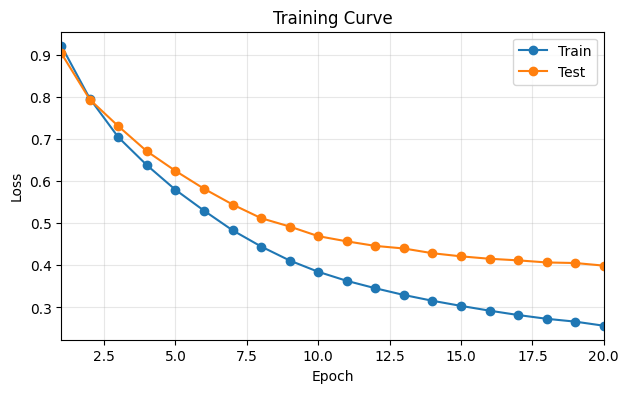

Epoch 1 train loss = 0.9219 test loss = 0.9040
Epoch 2 train loss = 0.7962 test loss = 0.7939
Epoch 3 train loss = 0.7042 test loss = 0.7305
Epoch 4 train loss = 0.6379 test loss = 0.6709
Epoch 5 train loss = 0.5795 test loss = 0.6244
Epoch 6 train loss = 0.5299 test loss = 0.5820
Epoch 7 train loss = 0.4832 test loss = 0.5446
Epoch 8 train loss = 0.4448 test loss = 0.5121
Epoch 9 train loss = 0.4115 test loss = 0.4922
Epoch 10 train loss = 0.3847 test loss = 0.4694
Epoch 11 train loss = 0.3632 test loss = 0.4570
Epoch 12 train loss = 0.3456 test loss = 0.4462
Epoch 13 train loss = 0.3296 test loss = 0.4401
Epoch 14 train loss = 0.3159 test loss = 0.4288
Epoch 15 train loss = 0.3037 test loss = 0.4214
Epoch 16 train loss = 0.2924 test loss = 0.4157
Epoch 17 train loss = 0.2820 test loss = 0.4119
Epoch 18 train loss = 0.2731 test loss = 0.4069
Epoch 19 train loss = 0.2663 test loss = 0.4055
Epoch 20 train loss = 0.2566 test loss = 0.3994
Loss curve refreshed at: /Users/jackychung/Docume

In [18]:
train_losses = []
test_losses = []
best_test_loss = float("inf")

for epoch in range(1, cfg.NUM_EPOCHS + 1):
    train_loss = run_train_epoch(model, train_loader, optimizer)
    test_loss = run_test_epoch(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), cfg.BEST_CHECKPOINT_PATH)

    fig = plot_loss_curve(train_losses, test_losses, num_epochs=cfg.NUM_EPOCHS, title="Training Curve")
    fig.savefig(cfg.LOSS_CURVE_PATH, dpi=150, bbox_inches="tight")
    clear_output(wait=True)
    display(fig)
    plt.close(fig)

    for completed_epoch, (train_value, test_value) in enumerate(zip(train_losses, test_losses), start=1):
        print(f"Epoch {completed_epoch} train loss = {train_value:.4f} test loss = {test_value:.4f}")
    print(f"Loss curve refreshed at: {cfg.LOSS_CURVE_PATH}")

torch.save(model.state_dict(), cfg.FINAL_CHECKPOINT_PATH)

print("Best checkpoint saved to: ", cfg.BEST_CHECKPOINT_PATH)
print("Final checkpoint saved to:", cfg.FINAL_CHECKPOINT_PATH)


## 10. Visualize One Test Prediction

The plot compares coarse input, model prediction, and fine target for one held-out test sample. The prediction is made by adding the model residual back to the coarse field.

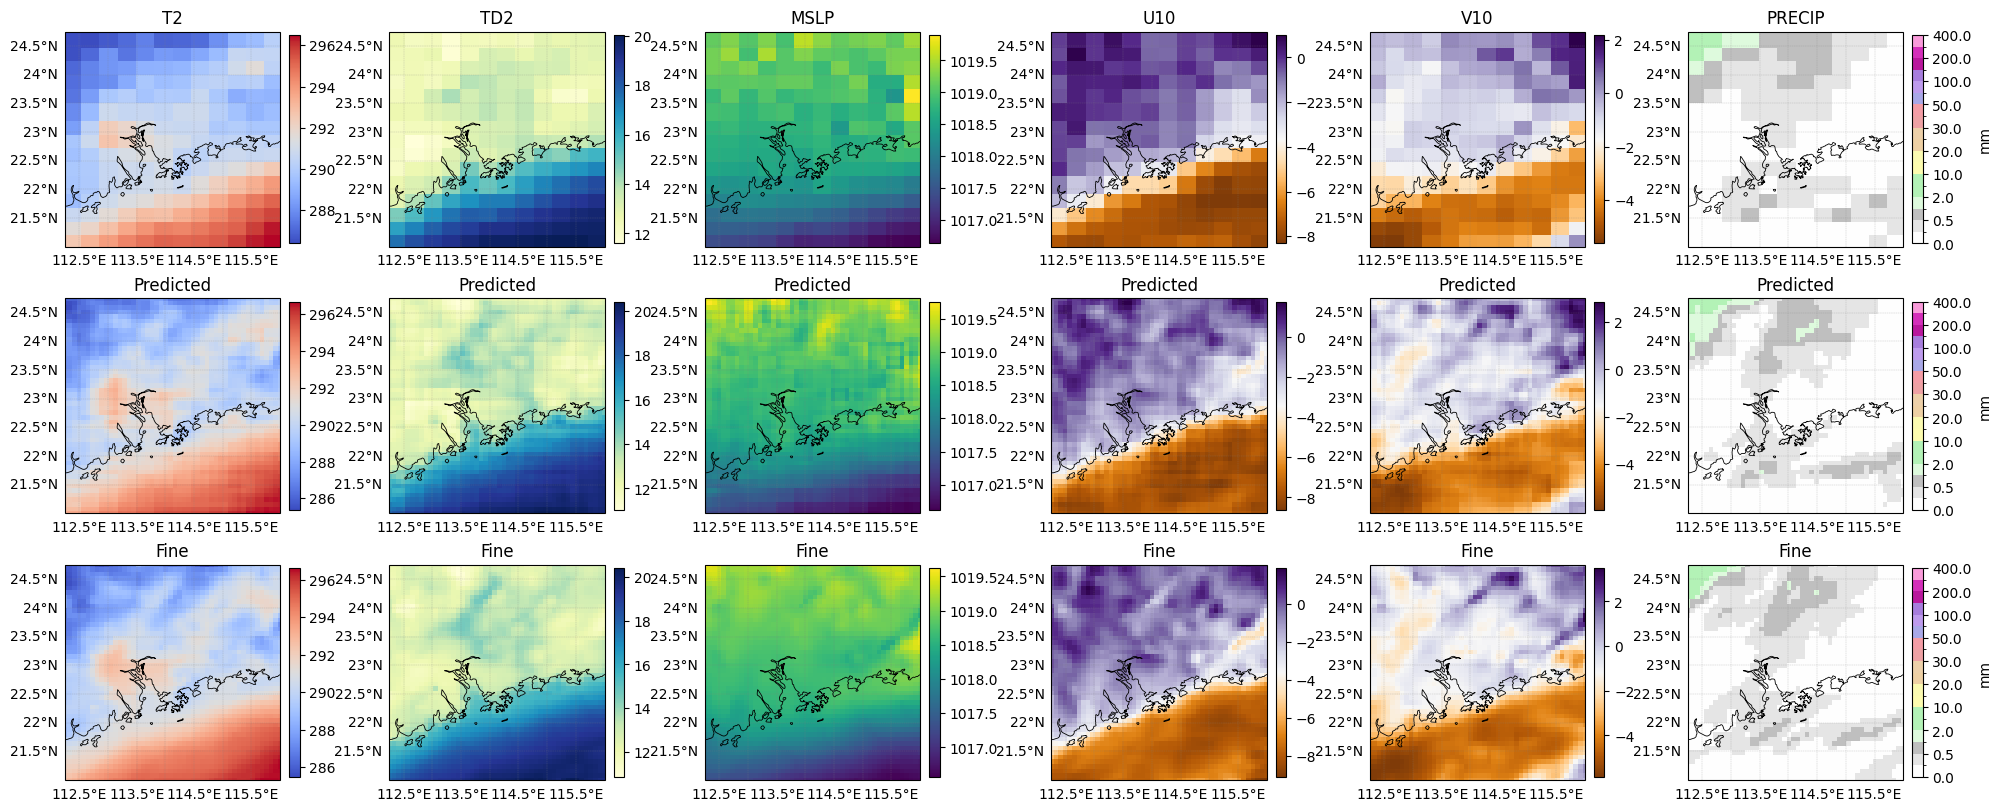

In [19]:
fig = plot_prediction_example(model, test_dataset, cfg.DL_OUT_SINGLE_LAYER_PARAMS, DEVICE, index=10)
display(fig)
plt.close(fig)


## 11. Reload The Best Checkpoint For Inference

The model at the final epoch is not always the best model. Reloading the best checkpoint makes the inference output match the checkpoint selected by the test loss.

In [20]:
model.load_state_dict(torch.load(cfg.CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

print("Loaded checkpoint for inference:", cfg.CHECKPOINT_PATH)

Loaded checkpoint for inference: /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching/outputs/unet_npz_best.pt


## 12. Predict One Dataset

The model predicts normalized residuals. The dataset helper converts those residuals back to physical units and adds them to the coarse field.

In [21]:
def predict_dataset(model, dataset, batch_size):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    coarse_batches = []
    fine_batches = []
    predicted_batches = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inference", leave=False):
            inputs = batch["inputs"].to(DEVICE)
            condition = batch["condition"].to(DEVICE)

            residual_prediction = model(inputs, class_labels=condition)
            residual_prediction = residual_prediction.cpu()

            predicted_fine = dataset.residual_to_fine(residual_prediction, batch["coarse"])

            coarse_batches.append(batch["coarse"])
            fine_batches.append(batch["fine"])
            predicted_batches.append(predicted_fine)

    coarse = torch.cat(coarse_batches, dim=0).numpy().astype(np.float32)
    fine = torch.cat(fine_batches, dim=0).numpy().astype(np.float32)
    predicted = torch.cat(predicted_batches, dim=0).numpy().astype(np.float32)

    return coarse, fine, predicted

## 13. Run Inference Year By Year

Saving separate files by year keeps the inference outputs organized. By default, `cfg.INFERENCE_YEARS` uses the same held-out year as testing.

In [22]:
all_outputs = {}

for year in cfg.INFERENCE_YEARS:
    inference_dataset = WRFNPZDataset(
        years=[year],
        data_dir=cfg.DATA_DIR,
        static_npz_path=cfg.STATIC_NPZ_PATH,
        raw_mean=raw_mean,
        raw_std=raw_std,
        residual_mean=residual_mean,
        residual_std=residual_std,
        output_shape=cfg.HIGH_RES_SHP,
    )

    coarse, fine, predicted = predict_dataset(model, inference_dataset, cfg.BATCH_SIZE)
    saved_path = save_predicted_year_npz(cfg.DATA_DIR, year, inference_dataset, predicted)

    all_outputs[year] = {
        "coarse": coarse,
        "fine": fine,
        "predicted": predicted,
        "saved_path": saved_path,
    }

    print("Year", year)
    print("  coarse shape:   ", coarse.shape)
    print("  fine shape:     ", fine.shape)
    print("  predicted shape:", predicted.shape)
    print("  saved", saved_path)


Year 2018
  coarse shape:    (940, 6, 48, 48)
  fine shape:      (940, 6, 48, 48)
  predicted shape: (940, 6, 48, 48)
  saved /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching/data/wrf_2018_predicted.npz


## 14. Visualize One Inference Result

Plot one saved inference timestep to compare the coarse input, model prediction, and fine target.

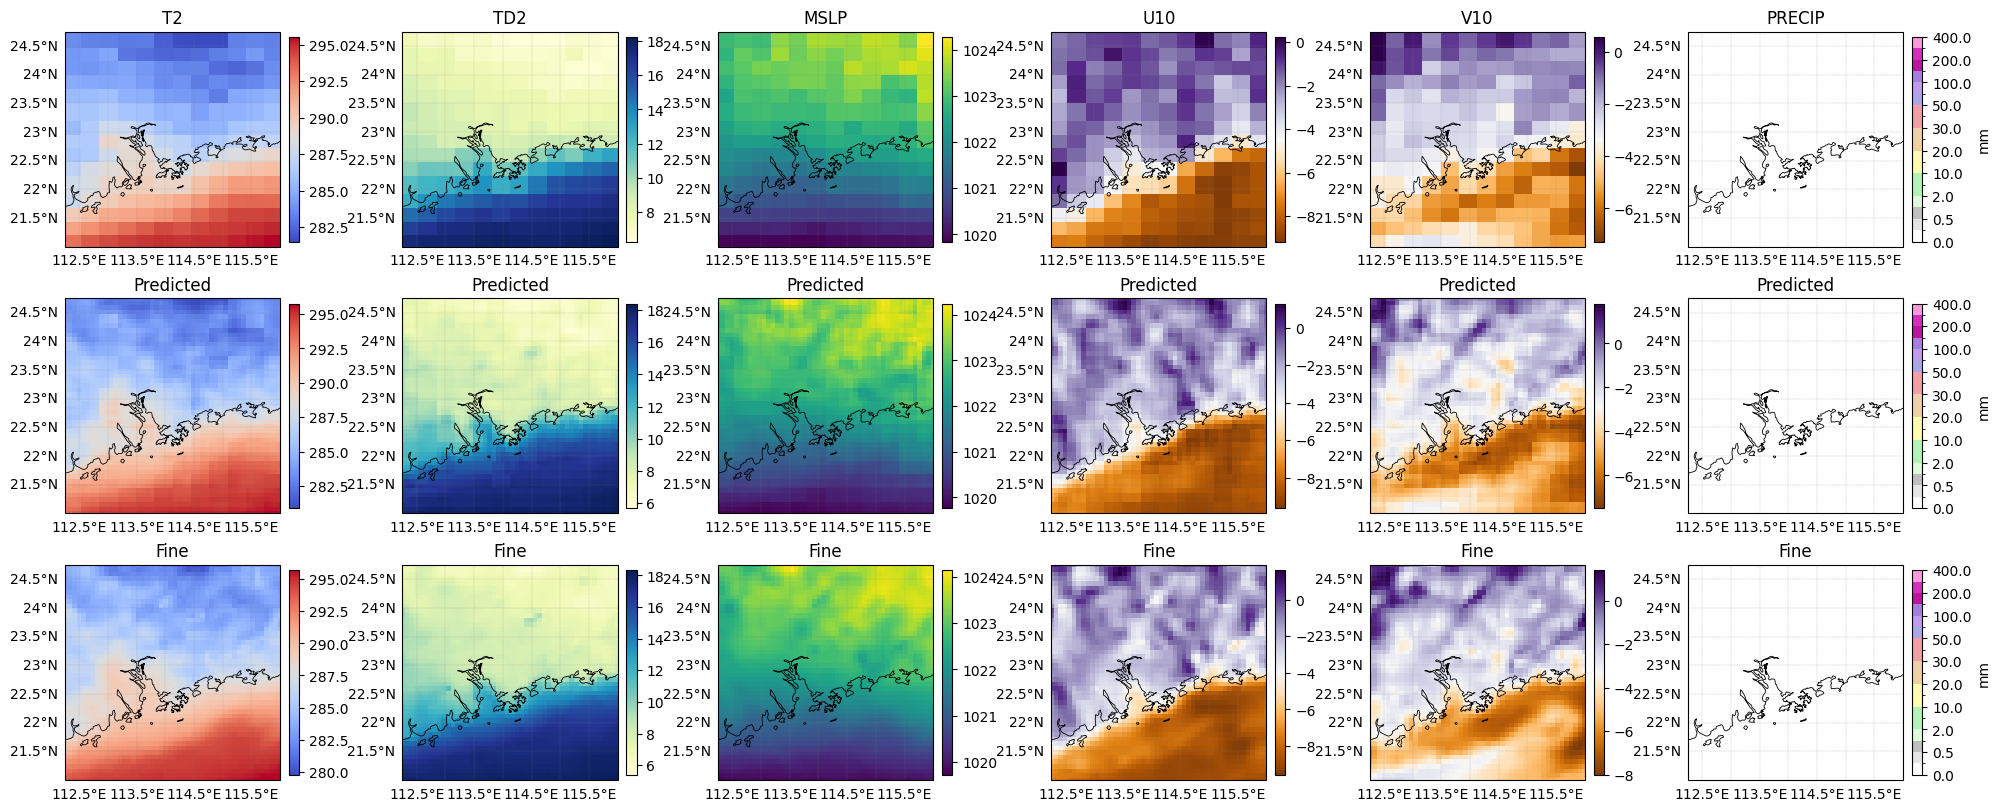

In [23]:
first_year = cfg.INFERENCE_YEARS[0]
fig = plot_saved_prediction(all_outputs, cfg.DL_OUT_SINGLE_LAYER_PARAMS, first_year, index=0)
display(fig)
plt.close(fig)